# Import & Setup

In [1]:
import os
if os.path.exists('digit_recognizer'):
    !rm -rf digit_recognizer
!git clone https://github.com/Sirius-Siru/digit_recognizer.git

import sys
if '/content/digit_recognizer' not in sys.path:
    sys.path.append('/content/digit_recognizer')

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

if os.path.isdir('data') and os.path.exists('data/train.csv'):
    print("✨ Dữ liệu đã sẵn sàng, không cần tải lại.")
else:
    print("🚀 Đang tải dữ liệu...")
    !kaggle competitions download -c digit-recognizer
    !unzip -o digit-recognizer.zip -d data
    !rm -f digit-recognizer.zip

Cloning into 'digit_recognizer'...
remote: Enumerating objects: 202, done.
remote: Counting objects: 100% (202/202), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 202 (delta 109), reused 152 (delta 60), pack-reused 0 (from 0)
Receiving objects: 100% (202/202), 809.73 KiB | 13.72 MiB/s, done.
Resolving deltas: 100% (109/109), done.
✨ Dữ liệu đã sẵn sàng, không cần tải lại.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import src.preprocessing as pp

import gc
from joblib import Parallel, delayed

# Load data

In [3]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

X = train.drop('label', axis=1)
y = train['label']

# Unflatten & Normalize
train_img = X.values.reshape(-1, 28, 28) / 255.0
test_img = test.values.reshape(-1, 28, 28) / 255.0

# Preprocessing

In [4]:
X = Parallel(n_jobs = -1)(delayed(pp.cnn_preprocess)(img) for img in train_img)
test = Parallel(n_jobs = -1)(delayed(pp.cnn_preprocess)(img) for img in test_img)

X = np.array(X)
test = np.array(test)

del train_img, test_img
gc.collect()

54

# Setup model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def random_dilation(image):
    # kernel 3x3
    kernel = tf.ones((3, 3, 1))
    image = tf.nn.dilation2d(
        image,
        filters=kernel,
        strides=[1,1,1,1],
        padding="SAME",
        dilations=[1,1,1,1]
    )
    return image

data_augmentation = models.Sequential([
  layers.RandomRotation(0.05, input_shape=(28, 28, 1)),
  layers.RandomZoom(0.05),
  layers.RandomTranslation(0.05, 0.05),
  layers.Lambda(lambda x: random_dilation(x))
])

model = models.Sequential([

    # Lớp Conv đầu tiên: Tìm các nét thẳng, cong (như cái bụng số 9)
    layers.Input(shape=(28, 28, 1)),
    #data_augmentation,
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    
    # Lớp Conv thứ hai: Kết hợp các nét thành hình dạng phức tạp hơn
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Phẳng hóa để đưa vào lớp phân loại cuối cùng
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 đầu ra tương ứng 10 chữ số
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
# Train-Test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Train model

In [7]:
print(y[len(y) * 90 // 100 :].value_counts().sort_index())

label
0    455
1    458
2    392
3    448
4    438
5    354
6    413
7    421
8    397
9    424
Name: count, dtype: int64


In [8]:
print(type(X))

<class 'numpy.ndarray'>


In [9]:
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 67s 140ms/step - accuracy: 0.9266 - loss: 0.2369 - val_accuracy: 0.9729 - val_loss: 0.0938
Epoch 2/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - accuracy: 0.9785 - loss: 0.0716 - val_accuracy: 0.9744 - val_loss: 0.0786
Epoch 3/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 67s 142ms/step - accuracy: 0.9839 - loss: 0.0523 - val_accuracy: 0.9807 - val_loss: 0.0592
Epoch 4/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 68s 144ms/step - accuracy: 0.9881 - loss: 0.0386 - val_accuracy: 0.9854 - val_loss: 0.0477
Epoch 5/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 65s 137ms/step - accuracy: 0.9899 - loss: 0.0319 - val_accuracy: 0.9830 - val_loss: 0.0569


263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
Accuracy = 98.49


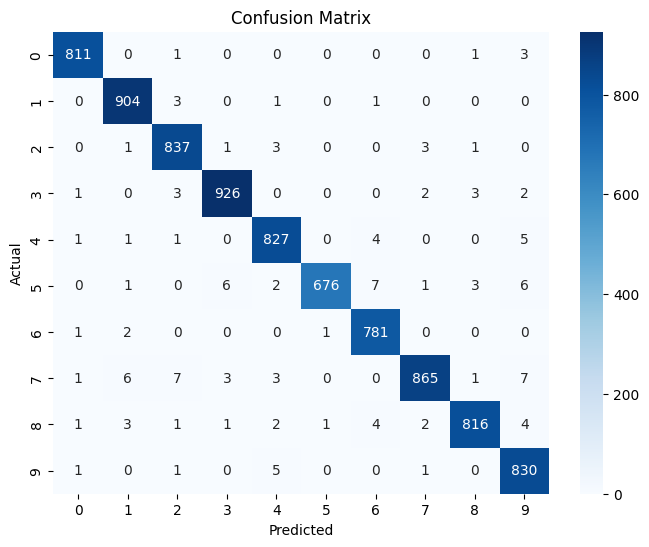

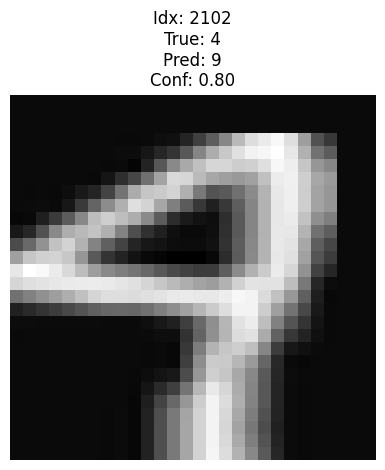

In [10]:
import src.evaluate as eva
probs = model.predict(X_val)
y_pred = np.argmax(probs, axis=1)
eva.evaluate(y_val, y_pred)
eva.showWrongCase(model, X_val, y_val, probs) 

# Submission

In [11]:
#submission = model.predict(test)

In [12]:
# labels = np.argmax(submission, axis = 1)
# submission = pd.DataFrame(data = labels, columns=['Label'])
# submission.insert(0, 'ImageId', range(1, len(submission)+1))
# submission.to_csv('submission.csv', index = False)

In [13]:
# !kaggle competitions submit -c digit-recognizer -f submission.csv  -m "First submit of the day"